In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Python environment is ready.")

Python environment is ready.


In [5]:
import sys
!{sys.executable} -m pip install yfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 12.9 MB/s eta 0:00:00
  Attempting uninstall: cffi0m╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/6 [websockets]
    Found existing installation: cffi 1.17.1━━━━━━━━━━━━━━━━━━ 2/6 [websockets]
    Uninstalling cffi-1.17.1:0m━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/6 [websockets]
      Successfully uninstalled cffi-1.17.1━━━━━━━━━━━━━━━━━━━ 3/6 [cffi]s]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [yfinance]5/6 [yfinance]]

[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: /usr/local/anaconda3/bin/python -m pip install --upgrade pip


In [6]:
import yfinance as yf

print("yfinance is ready.")

yfinance is ready.


In [7]:
# 设置股票代码
tickers = ["NVDA", "MSFT", "AMZN", "META", "AAPL", "AVGO", "V", "INTU", "NFLX", "LLY"]

# 设置数据时间区间
start_date = "2020-01-01"
end_date = "2025-12-31"

print("Selected tickers:", tickers)

Selected tickers: ['NVDA', 'MSFT', 'AMZN', 'META', 'AAPL', 'AVGO', 'V', 'INTU', 'NFLX', 'LLY']


In [8]:
# 下载月度股票价格数据
raw_data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    interval="1mo",
    auto_adjust=True
)

raw_data.head()

[*********************100%***********************]  10 of 10 completed

1 Failed download:
['MSFT']: OperationalError('database is locked')


Price      Adj Close      Close                                     \
Ticker          MSFT       AAPL        AMZN       AVGO        INTU   
Date                                                                 
2020-01-01       NaN  74.608582  100.435997  26.198284  268.346069   
2020-02-01       NaN  65.894463   94.187500  23.404694  254.934738   
2020-03-01       NaN  61.443054   97.486000  20.355265  220.556671   
2020-04-01       NaN  70.989685  123.699997  23.715208  258.732147   
2020-05-01       NaN  76.822540  122.118500  25.430857  279.001373   

Price                                                         ...      Volume  \
Ticker             LLY        META MSFT       NFLX      NVDA  ...        AAPL   
Date                                                          ...               
2020-01-01  129.693924  200.337845  NaN  34.508999  5.884146  ...  2934370400   
2020-02-01  117.146187  190.971359  NaN  36.903000  6.721360  ...  3019279200   
2020-03-01  129.507217  165.501236  NaN  37.549999  6.564263  ...  6280072400   
2020-04-01  144.369919  203.116043  NaN  41.985001  7.278462  ...  3265299200   
2020-05-01  142.792191  223.337341  NaN  41.973000  8.840834  ...  2805936000   

Price                                                                    \
Ticker            AMZN        AVGO      INTU        LLY       META MSFT   
Date                                                                      
2020-01-01  1693966000   585943000  26141100   76636200  347314600  NaN   
2020-02-01  1850202000   458786000  26559200   73120500  317547300  NaN   
2020-03-01  3276182000  1195556000  54282200  150278300  649467700  NaN   
2020-04-01  2492196000   619989000  29428200   79568600  541334600  NaN   
2020-05-01  1651688000   419535000  24780800   65390700  509476500  NaN   

Price                                           
Ticker            NFLX         NVDA          V  
Date                                            
2020-01-01  1698740000   6125412000  184029800  
2020-02-01  1140560000  11848652000  199936300  
2020-03-01  2019791000  15773952000  417986300  
2020-04-01  2251116000  11278304000  263788900  
2020-05-01  1350558000  12548876000  189859400  

[5 rows x 51 columns]

In [9]:
# 提取调整后的收盘价
prices = raw_data["Close"]

# 查看前几行数据
prices.head()

Ticker,AAPL,AMZN,AVGO,INTU,LLY,META,MSFT,NFLX,NVDA,V
Date,,,,,,,,,,
2020-01-01,74.608582,100.435997,26.198284,268.346069,129.693924,200.337845,NaN,34.508999,5.884146,190.317902
2020-02-01,65.894463,94.187500,23.404694,254.934738,117.146187,190.971359,NaN,36.903000,6.721360,173.856247
2020-03-01,61.443054,97.486000,20.355265,220.556671,129.507217,165.501236,NaN,37.549999,6.564263,154.336990
2020-04-01,70.989685,123.699997,23.715208,258.732147,144.369919,203.116043,NaN,41.985001,7.278462,171.196045
2020-05-01,76.822540,122.118500,25.430857,279.001373,142.792191,223.337341,NaN,41.973000,8.840834,187.020599


In [10]:
print("开始日期:", prices.index.min())
print("结束日期:", prices.index.max())
print("数据行数:", len(prices))

prices.tail()

开始日期: 2020-01-01 00:00:00
结束日期: 2025-12-01 00:00:00
数据行数: 72


Ticker,AAPL,AMZN,AVGO,INTU,LLY,META,MSFT,NFLX,NVDA,V
Date,,,,,,,,,,
2025-08-01,231.435730,229.000000,295.694122,662.511902,728.686401,736.969238,NaN,120.824997,174.151047,349.746704
2025-09-01,254.145599,219.570007,328.028625,678.314819,760.611572,732.659363,NaN,119.891998,186.548996,340.004028
2025-10-01,269.855652,244.220001,368.151855,663.058167,860.158997,647.267456,NaN,111.886002,202.467773,339.366608
2025-11-01,278.319519,233.220001,401.348511,630.964417,1072.103516,646.868164,NaN,107.580002,176.980560,333.092010
2025-12-01,271.605835,230.820007,344.715942,659.165161,1072.889404,658.987854,NaN,93.760002,186.479538,349.988281


In [15]:
import os

# 确认当前 notebook 所在位置
print("当前路径:", os.getcwd())

# 自动创建 raw 和 processed 文件夹，如果已经存在就不会重复创建
os.makedirs("../data/raw", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

# 再次确认文件夹是否存在
print("data 文件夹内容:", os.listdir("../data"))

# 保存原始价格数据
prices.to_csv("../data/raw/monthly_stock_prices.csv")

print("保存成功：monthly_stock_prices.csv")

当前路径: /Users/kxyk/Desktop/stock-portfolio-risk-return-analysis/notebooks
data 文件夹内容: ['.ipynb_checkpoints', 'processed', 'raw', 'raw data']
保存成功：monthly_stock_prices.csv


In [17]:
# 计算月度收益率
monthly_returns = prices.pct_change(fill_method=None).dropna()

# 保存处理后的收益率数据
monthly_returns.to_csv("../data/processed/monthly_returns.csv")

print("保存成功：monthly_returns.csv")

# 查看收益率前几行
monthly_returns.head()

保存成功：monthly_returns.csv


Ticker,AAPL,AMZN,AVGO,INTU,LLY,META,MSFT,NFLX,NVDA,V
Date,,,,,,,,,,


In [19]:
# 先检查价格表
print("价格表行数和列数:", prices.shape)
print("每只股票缺失值数量:")
print(prices.isna().sum())

# 不要直接 dropna 删除所有含缺失值的行
# 先计算收益率
monthly_returns = prices.pct_change(fill_method=None)

# 删除所有股票都为空的行
monthly_returns = monthly_returns.dropna(how="all")

# 如果个别股票有少量缺失值，用该股票的平均月收益率填补
monthly_returns = monthly_returns.fillna(monthly_returns.mean())

print("收益率表行数和列数:", monthly_returns.shape)

monthly_returns.head()

价格表行数和列数: (72, 10)
每只股票缺失值数量:
Ticker
AAPL     0
AMZN     0
AVGO     0
INTU     0
LLY      0
META     0
MSFT    72
NFLX     0
NVDA     0
V        0
dtype: int64
收益率表行数和列数: (71, 10)


Ticker,AAPL,AMZN,AVGO,INTU,LLY,META,MSFT,NFLX,NVDA,V
Date,,,,,,,,,,
2020-02-01,-0.116798,-0.062214,-0.106633,-0.049978,-0.096749,-0.046753,NaN,0.069373,0.142283,-0.086496
2020-03-01,-0.067554,0.035021,-0.130291,-0.134850,0.105518,-0.133371,NaN,0.017532,-0.023373,-0.112272
2020-04-01,0.155374,0.268900,0.165065,0.173087,0.114763,0.227278,NaN,0.118109,0.108801,0.109235
2020-05-01,0.082165,-0.012785,0.072344,0.078341,-0.010928,0.099555,NaN,-0.000286,0.214657,0.092435
2020-06-01,0.150492,0.129567,0.083565,0.020219,0.078476,0.008797,NaN,0.084126,0.070109,-0.008946


In [20]:
# 单独重新下载 MSFT 的月度价格数据
msft_data = yf.download(
    "MSFT",
    start=start_date,
    end=end_date,
    interval="1mo",
    auto_adjust=True
)

msft_data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
2020-01-01,161.262146,164.880912,148.264925,150.415344,558530000
2020-02-01,153.475174,180.653763,143.992514,161.451600,887522300
2020-03-01,149.809753,166.233630,125.881607,157.029034,1612695500
2020-04-01,170.232773,171.363150,142.827961,145.335714,984705000
2020-05-01,174.070374,178.116970,165.093760,166.993573,688845000


In [21]:
# 提取 MSFT 的收盘价
msft_price = msft_data["Close"]

# 把 MSFT 数据替换回原来的 prices 表
prices["MSFT"] = msft_price

# 再次检查缺失值
prices.isna().sum()

/var/folders/hf/sps21hls3h54628vy5vcg82w0000gn/T/ipykernel_38787/976080148.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prices["MSFT"] = msft_price


Ticker
AAPL    0
AMZN    0
AVGO    0
INTU    0
LLY     0
META    0
MSFT    0
NFLX    0
NVDA    0
V       0
dtype: int64

In [22]:
# 重新计算月度收益率
monthly_returns = prices.pct_change(fill_method=None).dropna()

# 检查收益率数据
print("收益率表行数和列数:", monthly_returns.shape)
print("每只股票缺失值数量:")
print(monthly_returns.isna().sum())

monthly_returns.head()

收益率表行数和列数: (71, 10)
每只股票缺失值数量:
Ticker
AAPL    0
AMZN    0
AVGO    0
INTU    0
LLY     0
META    0
MSFT    0
NFLX    0
NVDA    0
V       0
dtype: int64


Ticker,AAPL,AMZN,AVGO,INTU,LLY,META,MSFT,NFLX,NVDA,V
Date,,,,,,,,,,
2020-02-01,-0.116798,-0.062214,-0.106633,-0.049978,-0.096749,-0.046753,-0.048288,0.069373,0.142283,-0.086496
2020-03-01,-0.067554,0.035021,-0.130291,-0.134850,0.105518,-0.133371,-0.023883,0.017532,-0.023373,-0.112272
2020-04-01,0.155374,0.268900,0.165065,0.173087,0.114763,0.227278,0.136326,0.118109,0.108801,0.109235
2020-05-01,0.082165,-0.012785,0.072344,0.078341,-0.010928,0.099555,0.022543,-0.000286,0.214657,0.092435
2020-06-01,0.150492,0.129567,0.083565,0.020219,0.078476,0.008797,0.113653,0.084126,0.070109,-0.008946


In [23]:
# 保存修正后的价格数据
prices.to_csv("../data/raw/monthly_stock_prices.csv")

# 保存月度收益率数据
monthly_returns.to_csv("../data/processed/monthly_returns.csv")

print("修正后的价格数据和月度收益率数据已保存")

修正后的价格数据和月度收益率数据已保存


In [24]:
# 年化收益率：月度平均收益率 × 12
annualised_return = monthly_returns.mean() * 12

# 年化波动率：月度收益率标准差 × sqrt(12)
annualised_volatility = monthly_returns.std() * np.sqrt(12)

# 汇总成表格
risk_return_summary = pd.DataFrame({
    "Annualised Return": annualised_return,
    "Annualised Volatility": annualised_volatility
})

# 转换成百分比，方便阅读
risk_return_summary_percent = risk_return_summary * 100

risk_return_summary_percent

,Annualised Return,Annualised Volatility
Ticker,,
AAPL,25.800638,27.982985
AMZN,19.055548,31.953549
AVGO,50.587423,36.767253
INTU,19.210284,28.460675
LLY,41.323739,32.572246
META,28.582623,40.379055
MSFT,21.073509,22.398267
NFLX,26.126375,40.490114
NVDA,71.207916,48.615919


In [25]:
# 保存风险收益汇总表
risk_return_summary_percent.to_csv("../outputs/risk_return_summary.csv")

print("风险收益汇总表已保存到 outputs/risk_return_summary.csv")

风险收益汇总表已保存到 outputs/risk_return_summary.csv


In [26]:
# 按年化收益率从高到低排序
risk_return_summary_percent.sort_values(
    by="Annualised Return",
    ascending=False
)

,Annualised Return,Annualised Volatility
Ticker,,
NVDA,71.207916,48.615919
AVGO,50.587423,36.767253
LLY,41.323739,32.572246
META,28.582623,40.379055
NFLX,26.126375,40.490114
AAPL,25.800638,27.982985
MSFT,21.073509,22.398267
INTU,19.210284,28.460675
AMZN,19.055548,31.953549


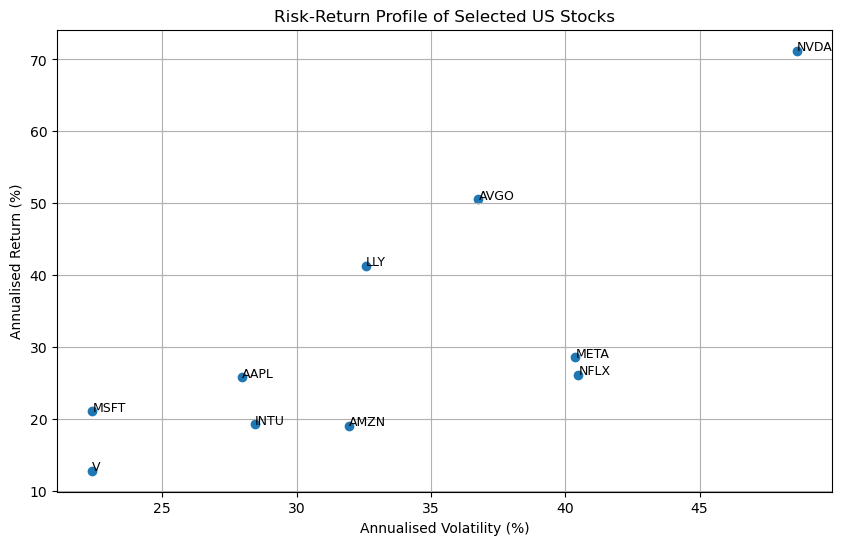

In [27]:
# 绘制风险收益散点图

plt.figure(figsize=(10, 6))

plt.scatter(
    risk_return_summary_percent["Annualised Volatility"],
    risk_return_summary_percent["Annualised Return"]
)

# 给每个点加股票代码标签
for ticker in risk_return_summary_percent.index:
    plt.text(
        risk_return_summary_percent.loc[ticker, "Annualised Volatility"],
        risk_return_summary_percent.loc[ticker, "Annualised Return"],
        ticker,
        fontsize=9
    )

plt.xlabel("Annualised Volatility (%)")
plt.ylabel("Annualised Return (%)")
plt.title("Risk-Return Profile of Selected US Stocks")
plt.grid(True)

plt.show()

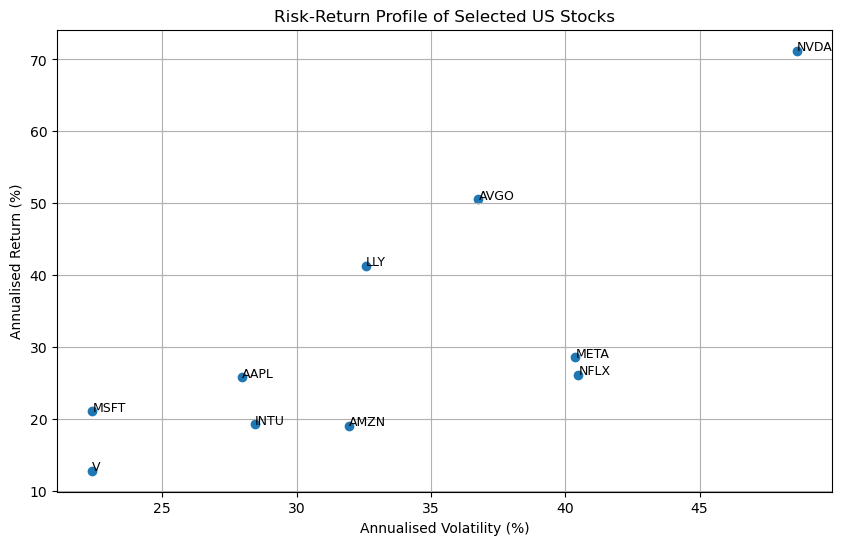

风险收益散点图已保存到 charts/risk_return_scatter.png


In [28]:
# 保存风险收益散点图
plt.figure(figsize=(10, 6))

plt.scatter(
    risk_return_summary_percent["Annualised Volatility"],
    risk_return_summary_percent["Annualised Return"]
)

for ticker in risk_return_summary_percent.index:
    plt.text(
        risk_return_summary_percent.loc[ticker, "Annualised Volatility"],
        risk_return_summary_percent.loc[ticker, "Annualised Return"],
        ticker,
        fontsize=9
    )

plt.xlabel("Annualised Volatility (%)")
plt.ylabel("Annualised Return (%)")
plt.title("Risk-Return Profile of Selected US Stocks")
plt.grid(True)

plt.savefig("../charts/risk_return_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

print("风险收益散点图已保存到 charts/risk_return_scatter.png")

In [29]:
# 计算每只股票的累计收益
cumulative_returns = (1 + monthly_returns).cumprod()

# 查看前几行
cumulative_returns.head()

Ticker,AAPL,AMZN,AVGO,INTU,LLY,META,MSFT,NFLX,NVDA,V
Date,,,,,,,,,,
2020-02-01,0.883202,0.937786,0.893367,0.950022,0.903251,0.953247,0.951712,1.069373,1.142283,0.913504
2020-03-01,0.823539,0.970628,0.776969,0.821911,0.998560,0.826111,0.928983,1.088122,1.115585,0.810943
2020-04-01,0.951495,1.231630,0.905220,0.964173,1.113159,1.013868,1.055628,1.216639,1.236962,0.899527
2020-05-01,1.029674,1.215884,0.970707,1.039707,1.100994,1.114804,1.079425,1.216291,1.502484,0.982675
2020-06-01,1.184632,1.373422,1.051824,1.060729,1.187395,1.124610,1.202104,1.318613,1.607822,0.973884


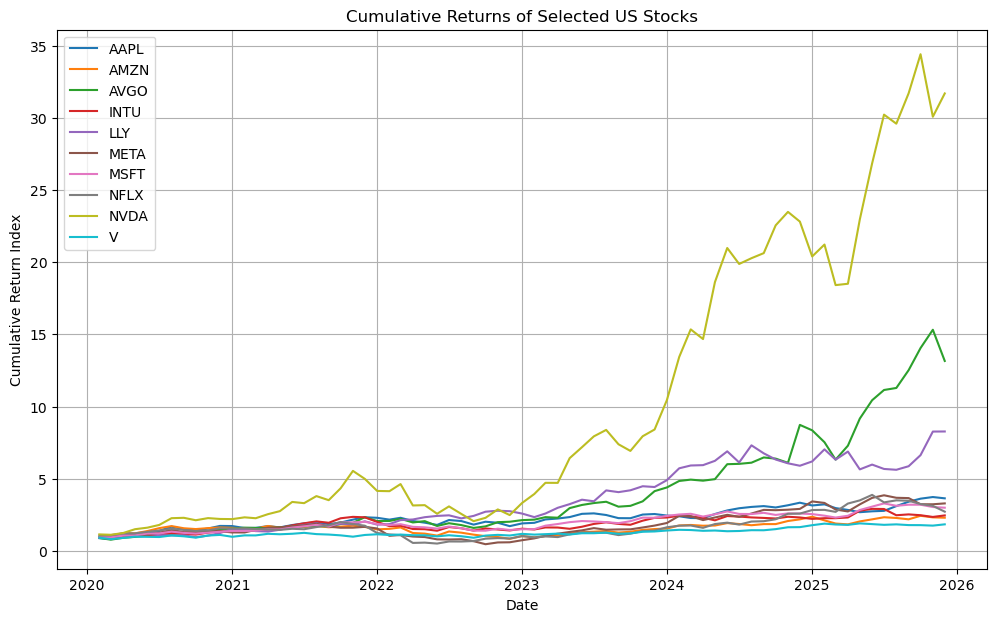

In [30]:
# 绘制各股票累计收益对比图
plt.figure(figsize=(12, 7))

for ticker in cumulative_returns.columns:
    plt.plot(cumulative_returns.index, cumulative_returns[ticker], label=ticker)

plt.xlabel("Date")
plt.ylabel("Cumulative Return Index")
plt.title("Cumulative Returns of Selected US Stocks")
plt.legend()
plt.grid(True)

plt.show()

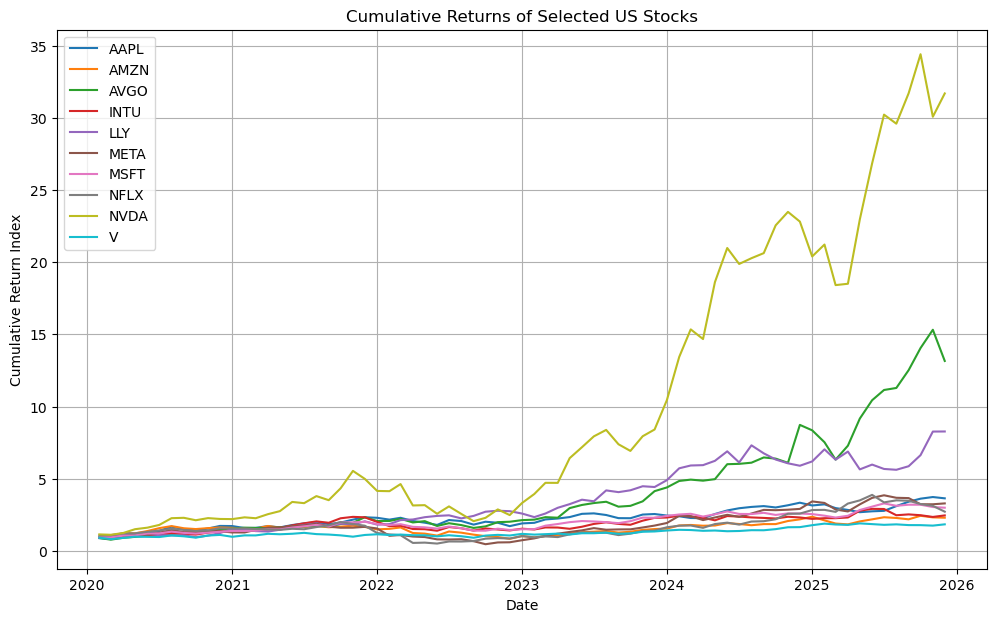

累计收益对比图已保存到 charts/cumulative_returns_stocks.png


In [31]:
# 保存累计收益对比图
plt.figure(figsize=(12, 7))

for ticker in cumulative_returns.columns:
    plt.plot(cumulative_returns.index, cumulative_returns[ticker], label=ticker)

plt.xlabel("Date")
plt.ylabel("Cumulative Return Index")
plt.title("Cumulative Returns of Selected US Stocks")
plt.legend()
plt.grid(True)

plt.savefig("../charts/cumulative_returns_stocks.png", dpi=300, bbox_inches="tight")
plt.show()

print("累计收益对比图已保存到 charts/cumulative_returns_stocks.png")

In [32]:
# 保存累计收益数据
cumulative_returns.to_csv("../outputs/cumulative_returns_stocks.csv")

print("累计收益数据已保存到 outputs/cumulative_returns_stocks.csv")

累计收益数据已保存到 outputs/cumulative_returns_stocks.csv


In [34]:
# Existing holdings original weights in the full portfolio
# These 10 stocks account for 59.40% of the original portfolio

existing_weights = {
    "NVDA": 0.0981,
    "MSFT": 0.0965,
    "AMZN": 0.0922,
    "META": 0.0633,
    "AAPL": 0.0535,
    "AVGO": 0.0481,
    "V": 0.0425,
    "INTU": 0.0368,
    "NFLX": 0.0338,
    "LLY": 0.0292
}

# Convert to Series and align with monthly_returns column order
existing_weights = pd.Series(existing_weights)
existing_weights = existing_weights[monthly_returns.columns]

print("Existing holdings total weight:", existing_weights.sum())

existing_weights

Existing holdings total weight: 0.594


Ticker
AAPL    0.0535
AMZN    0.0922
AVGO    0.0481
INTU    0.0368
LLY     0.0292
META    0.0633
MSFT    0.0965
NFLX    0.0338
NVDA    0.0981
V       0.0425
dtype: float64

In [35]:
# Save existing holdings weights
existing_weights_table = pd.DataFrame({
    "Original Weight": existing_weights,
    "Original Weight (%)": existing_weights * 100
})

existing_weights_table.to_csv("../outputs/existing_holdings_weights.csv")

existing_weights_table

,Original Weight,Original Weight (%)
Ticker,,
AAPL,0.0535,5.35
AMZN,0.0922,9.22
AVGO,0.0481,4.81
INTU,0.0368,3.68
LLY,0.0292,2.92
META,0.0633,6.33
MSFT,0.0965,9.65
NFLX,0.0338,3.38
NVDA,0.0981,9.81


In [36]:
# Normalise existing holdings weights to 100%
existing_sleeve_weights = existing_weights / existing_weights.sum()

print("Normalised existing sleeve weight sum:", existing_sleeve_weights.sum())

existing_sleeve_weights_table = pd.DataFrame({
    "Original Weight (%)": existing_weights * 100,
    "Normalised Sleeve Weight (%)": existing_sleeve_weights * 100
})

existing_sleeve_weights_table

Normalised existing sleeve weight sum: 1.0


,Original Weight (%),Normalised Sleeve Weight (%)
Ticker,,
AAPL,5.35,9.006734
AMZN,9.22,15.521886
AVGO,4.81,8.097643
INTU,3.68,6.195286
LLY,2.92,4.915825
META,6.33,10.656566
MSFT,9.65,16.245791
NFLX,3.38,5.690236
NVDA,9.81,16.515152


In [37]:
# Calculate monthly returns of the existing holdings sleeve portfolio
existing_sleeve_returns = monthly_returns.dot(existing_sleeve_weights)

# Calculate cumulative return index
existing_sleeve_cumulative = (1 + existing_sleeve_returns).cumprod()

# Combine into one table
existing_sleeve_results = pd.DataFrame({
    "Existing Sleeve Monthly Return": existing_sleeve_returns,
    "Existing Sleeve Cumulative Return": existing_sleeve_cumulative
})

existing_sleeve_results.head()

,Existing Sleeve Monthly Return,Existing Sleeve Cumulative Return
Date,,
2020-02-01,-0.028233,0.971767
2020-03-01,-0.043354,0.929636
2020-04-01,0.164336,1.082409
2020-05-01,0.071910,1.160245
2020-06-01,0.080670,1.253841


In [38]:
# Existing holdings sleeve risk-return metrics
existing_sleeve_annualised_return = existing_sleeve_returns.mean() * 12
existing_sleeve_annualised_volatility = existing_sleeve_returns.std() * np.sqrt(12)

existing_sleeve_summary = pd.DataFrame({
    "Metric": ["Annualised Return", "Annualised Volatility"],
    "Value": [
        existing_sleeve_annualised_return,
        existing_sleeve_annualised_volatility
    ],
    "Value (%)": [
        existing_sleeve_annualised_return * 100,
        existing_sleeve_annualised_volatility * 100
    ]
})

existing_sleeve_summary

,Metric,Value,Value (%)
0,Annualised Return,0.332298,33.229826
1,Annualised Volatility,0.246632,24.663165


In [39]:
# Save existing holdings sleeve results
existing_sleeve_results.to_csv("../outputs/existing_sleeve_portfolio_returns.csv")
existing_sleeve_summary.to_csv("../outputs/existing_sleeve_portfolio_summary.csv", index=False)

print("Existing holdings sleeve portfolio results saved.")

Existing holdings sleeve portfolio results saved.


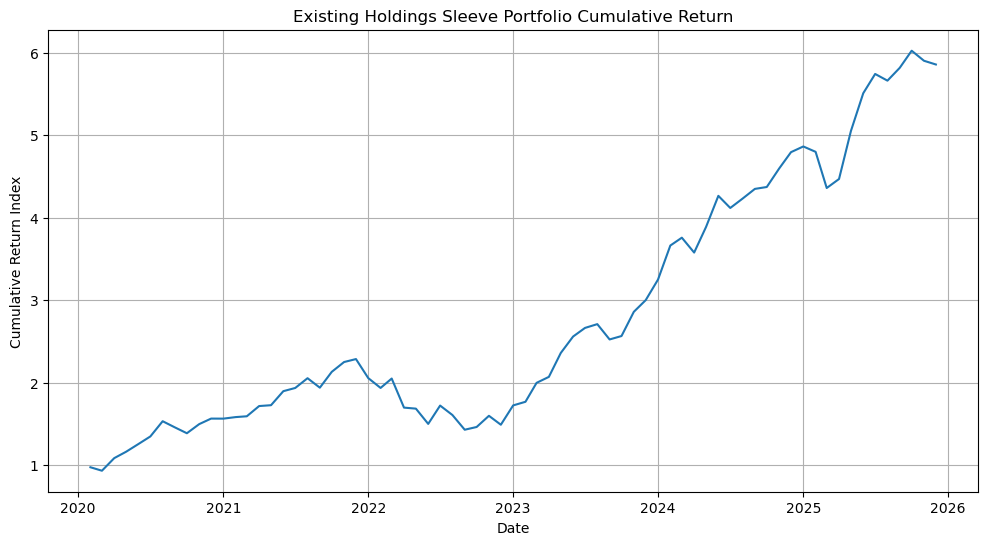

Existing sleeve portfolio cumulative return chart saved.


In [40]:
# Plot cumulative return of existing holdings sleeve portfolio
plt.figure(figsize=(12, 6))

plt.plot(
    existing_sleeve_cumulative.index,
    existing_sleeve_cumulative
)

plt.xlabel("Date")
plt.ylabel("Cumulative Return Index")
plt.title("Existing Holdings Sleeve Portfolio Cumulative Return")
plt.grid(True)

plt.savefig("../charts/existing_sleeve_portfolio_cumulative_return.png", dpi=300, bbox_inches="tight")
plt.show()

print("Existing sleeve portfolio cumulative return chart saved.")

In [41]:
# =========================
# Data Validation Check
# =========================

print("1. Price data shape:")
print(prices.shape)

print("\n2. Missing values in prices:")
print(prices.isna().sum())

print("\n3. Monthly returns shape:")
print(monthly_returns.shape)

print("\n4. Missing values in monthly returns:")
print(monthly_returns.isna().sum())

print("\n5. Existing holdings original weight sum:")
print(existing_weights.sum())

print("\n6. Existing sleeve normalised weight sum:")
print(existing_sleeve_weights.sum())

print("\n7. Existing sleeve returns shape:")
print(existing_sleeve_returns.shape)

print("\n8. Existing sleeve cumulative return first and last values:")
print(existing_sleeve_cumulative.iloc[0])
print(existing_sleeve_cumulative.iloc[-1])

1. Price data shape:
(72, 10)

2. Missing values in prices:
Ticker
AAPL    0
AMZN    0
AVGO    0
INTU    0
LLY     0
META    0
MSFT    0
NFLX    0
NVDA    0
V       0
dtype: int64

3. Monthly returns shape:
(71, 10)

4. Missing values in monthly returns:
Ticker
AAPL    0
AMZN    0
AVGO    0
INTU    0
LLY     0
META    0
MSFT    0
NFLX    0
NVDA    0
V       0
dtype: int64

5. Existing holdings original weight sum:
0.594

6. Existing sleeve normalised weight sum:
1.0

7. Existing sleeve returns shape:
(71,)

8. Existing sleeve cumulative return first and last values:
0.9717666847027276
5.858394365533353


In [42]:
# Create cumulative return index starting from 1.0

initial_date = prices.index[0]

existing_sleeve_cumulative_with_base = pd.concat([
    pd.Series([1.0], index=[initial_date]),
    existing_sleeve_cumulative
])

existing_sleeve_cumulative_with_base.head()

2020-01-01    1.000000
2020-02-01    0.971767
2020-03-01    0.929636
2020-04-01    1.082409
2020-05-01    1.160245
dtype: float64

In [43]:
# Save existing sleeve portfolio results with initial base value

existing_sleeve_results_with_base = pd.DataFrame({
    "Existing Sleeve Cumulative Return": existing_sleeve_cumulative_with_base
})

existing_sleeve_results_with_base.to_csv("../outputs/existing_sleeve_portfolio_cumulative_with_base.csv")

print("Existing sleeve cumulative return with base value saved.")

Existing sleeve cumulative return with base value saved.


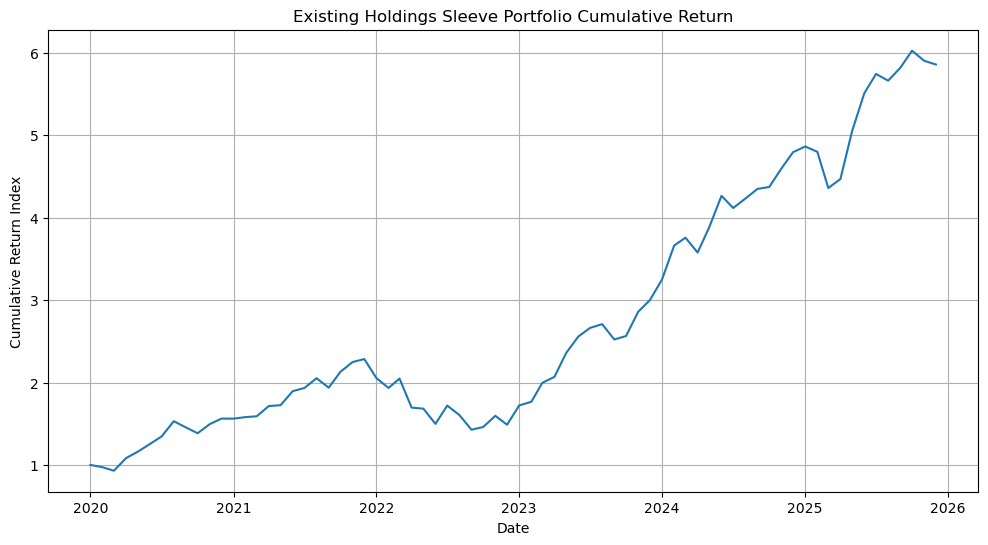

Updated existing sleeve cumulative return chart saved.


In [44]:
# Plot existing holdings sleeve portfolio cumulative return starting from 1.0

plt.figure(figsize=(12, 6))

plt.plot(
    existing_sleeve_cumulative_with_base.index,
    existing_sleeve_cumulative_with_base
)

plt.xlabel("Date")
plt.ylabel("Cumulative Return Index")
plt.title("Existing Holdings Sleeve Portfolio Cumulative Return")
plt.grid(True)

plt.savefig("../charts/existing_sleeve_portfolio_cumulative_return.png", dpi=300, bbox_inches="tight")
plt.show()

print("Updated existing sleeve cumulative return chart saved.")

In [45]:
# Calculate existing holdings contribution to the full portfolio
# This uses the original 59.40% weights without normalisation

existing_contribution_returns = monthly_returns.dot(existing_weights)

existing_contribution_returns.head()

Date
2020-02-01   -0.016771
2020-03-01   -0.025753
2020-04-01    0.097616
2020-05-01    0.042715
2020-06-01    0.047918
dtype: float64

In [46]:
# Calculate cumulative contribution index starting from 1.0

existing_contribution_cumulative = (1 + existing_contribution_returns).cumprod()

existing_contribution_cumulative_with_base = pd.concat([
    pd.Series([1.0], index=[prices.index[0]]),
    existing_contribution_cumulative
])

existing_contribution_cumulative_with_base.head()

2020-01-01    1.000000
2020-02-01    0.983229
2020-03-01    0.957909
2020-04-01    1.051416
2020-05-01    1.096326
dtype: float64

In [47]:
# Risk-return metrics of existing holdings contribution

existing_contribution_annualised_return = existing_contribution_returns.mean() * 12
existing_contribution_annualised_volatility = existing_contribution_returns.std() * np.sqrt(12)

existing_contribution_summary = pd.DataFrame({
    "Metric": ["Annualised Return Contribution", "Annualised Volatility Contribution"],
    "Value": [
        existing_contribution_annualised_return,
        existing_contribution_annualised_volatility
    ],
    "Value (%)": [
        existing_contribution_annualised_return * 100,
        existing_contribution_annualised_volatility * 100
    ]
})

existing_contribution_summary

,Metric,Value,Value (%)
0,Annualised Return Contribution,0.197385,19.738516
1,Annualised Volatility Contribution,0.146499,14.649920


In [48]:
# Save existing holdings contribution results

existing_contribution_results = pd.DataFrame({
    "Existing Holdings Contribution Monthly Return": existing_contribution_returns
})

existing_contribution_cumulative_table = pd.DataFrame({
    "Existing Holdings Contribution Cumulative Return": existing_contribution_cumulative_with_base
})

existing_contribution_results.to_csv("../outputs/existing_holdings_contribution_returns.csv")
existing_contribution_cumulative_table.to_csv("../outputs/existing_holdings_contribution_cumulative.csv")
existing_contribution_summary.to_csv("../outputs/existing_holdings_contribution_summary.csv", index=False)

print("Existing holdings contribution results saved.")

Existing holdings contribution results saved.


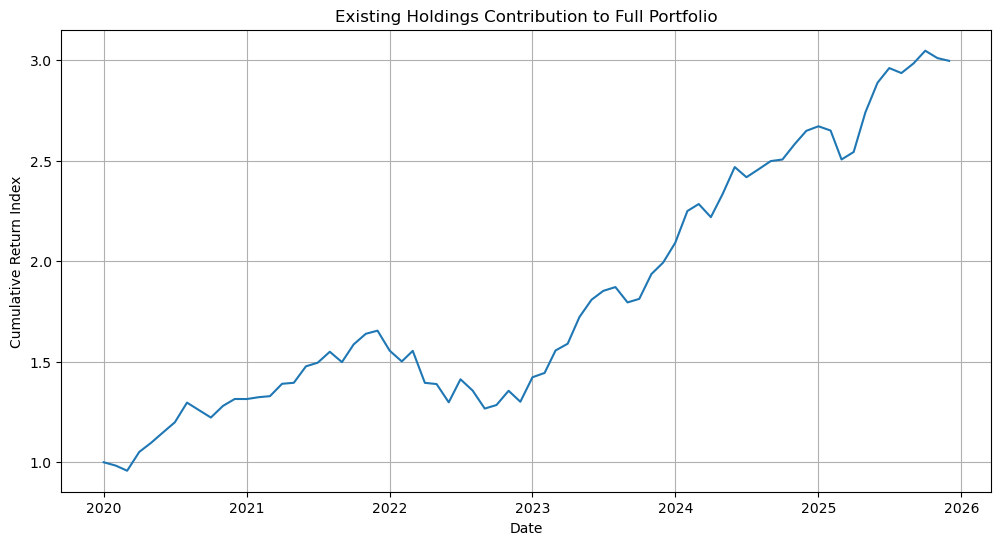

Existing holdings contribution chart saved.


In [49]:
# Plot existing holdings contribution cumulative return

plt.figure(figsize=(12, 6))

plt.plot(
    existing_contribution_cumulative_with_base.index,
    existing_contribution_cumulative_with_base
)

plt.xlabel("Date")
plt.ylabel("Cumulative Return Index")
plt.title("Existing Holdings Contribution to Full Portfolio")
plt.grid(True)

plt.savefig("../charts/existing_holdings_contribution_cumulative_return.png", dpi=300, bbox_inches="tight")
plt.show()

print("Existing holdings contribution chart saved.")

In [50]:
# Calculate correlation matrix of existing holdings monthly returns
correlation_matrix = monthly_returns.corr()

correlation_matrix

Ticker,AAPL,AMZN,AVGO,INTU,LLY,META,MSFT,NFLX,NVDA,V
Ticker,,,,,,,,,,
AAPL,1.000000,0.611774,0.425015,0.521716,0.197255,0.328886,0.566773,0.404368,0.485093,0.479242
AMZN,0.611774,1.000000,0.474184,0.559918,0.096420,0.490870,0.662811,0.570192,0.614462,0.346416
AVGO,0.425015,0.474184,1.000000,0.438914,0.188096,0.377753,0.555871,0.389403,0.469380,0.272370
INTU,0.521716,0.559918,0.438914,1.000000,0.118018,0.408228,0.674891,0.472291,0.551705,0.524760
LLY,0.197255,0.096420,0.188096,0.118018,1.000000,-0.037639,0.229173,0.199783,0.077756,0.107859
META,0.328886,0.490870,0.377753,0.408228,-0.037639,1.000000,0.565955,0.247565,0.516941,0.324123
MSFT,0.566773,0.662811,0.555871,0.674891,0.229173,0.565955,1.000000,0.515776,0.669099,0.352012
NFLX,0.404368,0.570192,0.389403,0.472291,0.199783,0.247565,0.515776,1.000000,0.558728,0.315943
NVDA,0.485093,0.614462,0.469380,0.551705,0.077756,0.516941,0.669099,0.558728,1.000000,0.274719


In [51]:
# Save correlation matrix
correlation_matrix.to_csv("../outputs/existing_holdings_correlation_matrix.csv")

print("Correlation matrix saved.")

Correlation matrix saved.


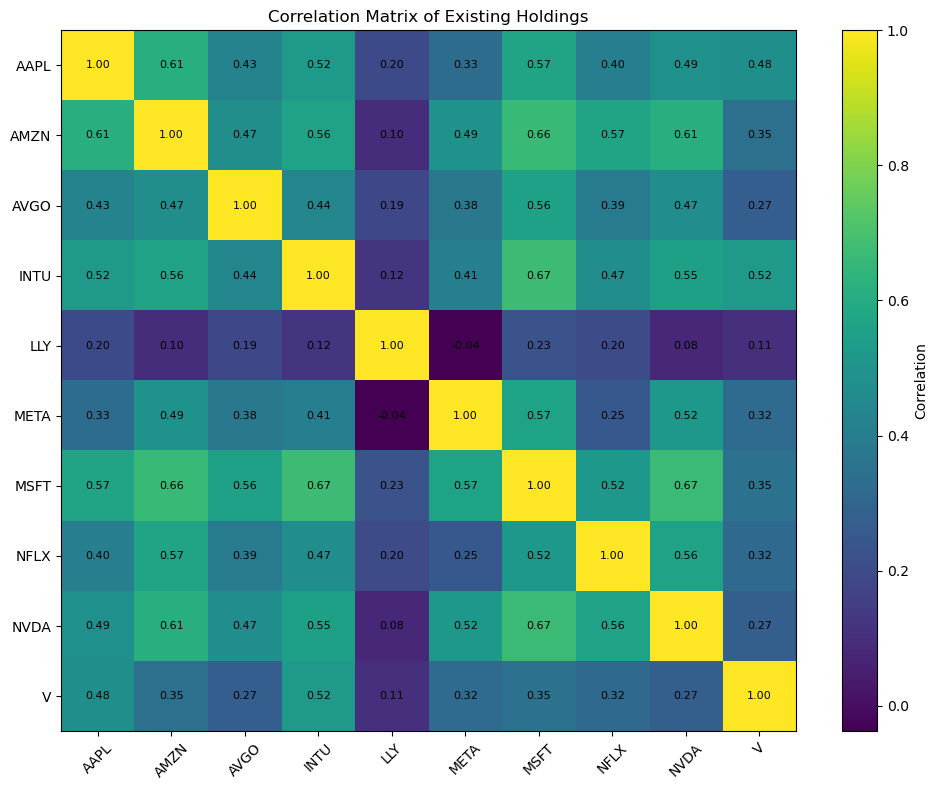

In [52]:
# Plot correlation matrix heatmap

plt.figure(figsize=(10, 8))

plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    ticks=range(len(correlation_matrix.columns)),
    labels=correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    ticks=range(len(correlation_matrix.index)),
    labels=correlation_matrix.index
)

plt.title("Correlation Matrix of Existing Holdings")

# Add correlation values inside the heatmap
for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.tight_layout()
plt.show()

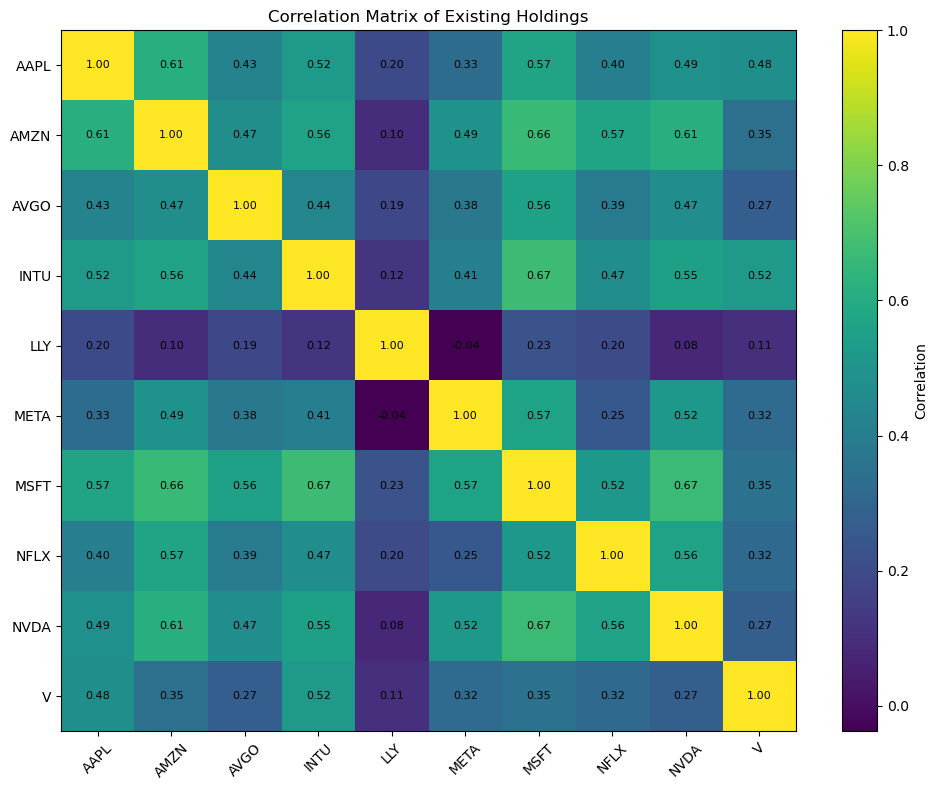

Correlation heatmap saved.


In [53]:
# Save correlation matrix heatmap

plt.figure(figsize=(10, 8))

plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    ticks=range(len(correlation_matrix.columns)),
    labels=correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    ticks=range(len(correlation_matrix.index)),
    labels=correlation_matrix.index
)

plt.title("Correlation Matrix of Existing Holdings")

for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.tight_layout()
plt.savefig("../charts/existing_holdings_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

print("Correlation heatmap saved.")

In [54]:
# Calculate maximum drawdown for each stock

# Cumulative return index for individual stocks, starting from 1
stock_cumulative_with_base = pd.concat([
    pd.DataFrame(
        [[1.0] * len(monthly_returns.columns)],
        index=[prices.index[0]],
        columns=monthly_returns.columns
    ),
    cumulative_returns
])

# Running maximum value for each stock
stock_running_max = stock_cumulative_with_base.cummax()

# Drawdown = current value / previous peak - 1
stock_drawdowns = stock_cumulative_with_base / stock_running_max - 1

# Maximum drawdown for each stock
stock_max_drawdown = stock_drawdowns.min()

stock_max_drawdown_percent = stock_max_drawdown * 100

stock_max_drawdown_percent

Ticker
AAPL   -26.404212
AMZN   -52.096765
AVGO   -31.831246
INTU   -40.760651
LLY    -23.168898
META   -75.444144
MSFT   -30.528483
NFLX   -74.667903
NVDA   -62.831687
V      -27.288876
dtype: float64

In [55]:
# Save maximum drawdown table for individual stocks

stock_max_drawdown_table = pd.DataFrame({
    "Maximum Drawdown": stock_max_drawdown,
    "Maximum Drawdown (%)": stock_max_drawdown_percent
})

stock_max_drawdown_table.to_csv("../outputs/stock_max_drawdown.csv")

stock_max_drawdown_table

,Maximum Drawdown,Maximum Drawdown (%)
Ticker,,
AAPL,-0.264042,-26.404212
AMZN,-0.520968,-52.096765
AVGO,-0.318312,-31.831246
INTU,-0.407607,-40.760651
LLY,-0.231689,-23.168898
META,-0.754441,-75.444144
MSFT,-0.305285,-30.528483
NFLX,-0.746679,-74.667903
NVDA,-0.628317,-62.831687


In [56]:
# Calculate maximum drawdown for existing holdings sleeve portfolio

existing_sleeve_running_max = existing_sleeve_cumulative_with_base.cummax()

existing_sleeve_drawdown = existing_sleeve_cumulative_with_base / existing_sleeve_running_max - 1

existing_sleeve_max_drawdown = existing_sleeve_drawdown.min()

print("Existing Sleeve Portfolio Maximum Drawdown:", existing_sleeve_max_drawdown)
print("Existing Sleeve Portfolio Maximum Drawdown (%):", existing_sleeve_max_drawdown * 100)

Existing Sleeve Portfolio Maximum Drawdown: -0.3753301638237573
Existing Sleeve Portfolio Maximum Drawdown (%): -37.53301638237573


In [57]:
# Save existing sleeve drawdown results

existing_sleeve_drawdown_table = pd.DataFrame({
    "Existing Sleeve Drawdown": existing_sleeve_drawdown
})

existing_sleeve_drawdown_summary = pd.DataFrame({
    "Metric": ["Maximum Drawdown"],
    "Value": [existing_sleeve_max_drawdown],
    "Value (%)": [existing_sleeve_max_drawdown * 100]
})

existing_sleeve_drawdown_table.to_csv("../outputs/existing_sleeve_drawdown_series.csv")
existing_sleeve_drawdown_summary.to_csv("../outputs/existing_sleeve_max_drawdown_summary.csv", index=False)

print("Existing sleeve drawdown results saved.")

Existing sleeve drawdown results saved.


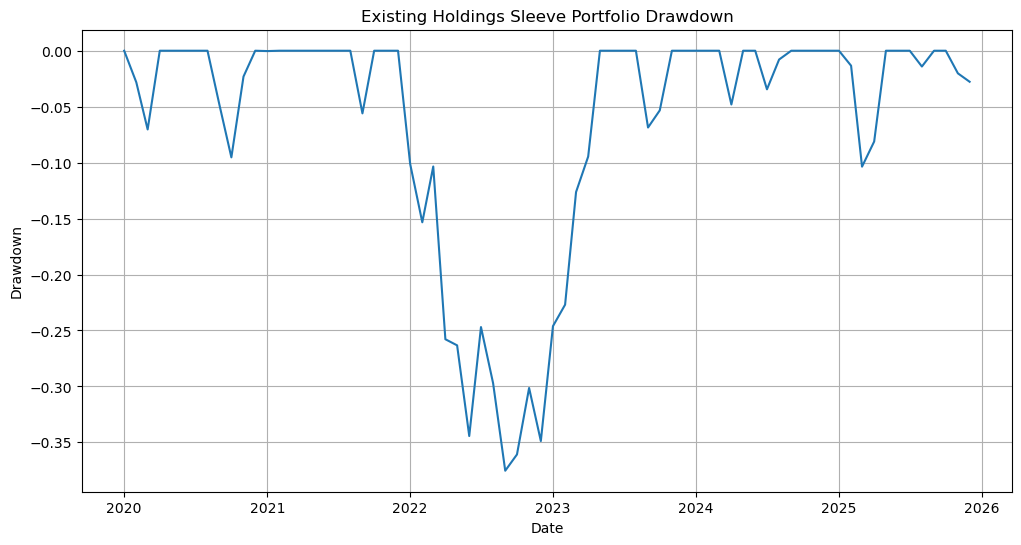

Existing sleeve drawdown chart saved.


In [58]:
# Plot existing sleeve portfolio drawdown

plt.figure(figsize=(12, 6))

plt.plot(
    existing_sleeve_drawdown.index,
    existing_sleeve_drawdown
)

plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.title("Existing Holdings Sleeve Portfolio Drawdown")
plt.grid(True)

plt.savefig("../charts/existing_sleeve_drawdown.png", dpi=300, bbox_inches="tight")
plt.show()

print("Existing sleeve drawdown chart saved.")

In [59]:
# Set annual risk-free rate
risk_free_rate = 0.0387

print("Annual risk-free rate:", risk_free_rate)

Annual risk-free rate: 0.0387


In [60]:
# Calculate Sharpe Ratio for each stock

risk_return_summary["Sharpe Ratio"] = (
    risk_return_summary["Annualised Return"] - risk_free_rate
) / risk_return_summary["Annualised Volatility"]

risk_return_summary_percent = risk_return_summary.copy()
risk_return_summary_percent["Annualised Return"] = risk_return_summary_percent["Annualised Return"] * 100
risk_return_summary_percent["Annualised Volatility"] = risk_return_summary_percent["Annualised Volatility"] * 100

risk_return_summary_percent

,Annualised Return,Annualised Volatility,Sharpe Ratio
Ticker,,,
AAPL,25.800638,27.982985,0.783713
AMZN,19.055548,31.953549,0.475238
AVGO,50.587423,36.767253,1.270626
INTU,19.210284,28.460675,0.538999
LLY,41.323739,32.572246,1.149867
META,28.582623,40.379055,0.612016
MSFT,21.073509,22.398267,0.768073
NFLX,26.126375,40.490114,0.549674
NVDA,71.207916,48.615919,1.385100


In [61]:
# Save updated risk-return summary with Sharpe Ratio

risk_return_summary_percent.to_csv("../outputs/risk_return_summary_with_sharpe.csv")

print("Risk-return summary with Sharpe Ratio saved.")

Risk-return summary with Sharpe Ratio saved.


In [62]:
# Calculate Sharpe Ratio for existing holdings sleeve portfolio

existing_sleeve_sharpe = (
    existing_sleeve_annualised_return - risk_free_rate
) / existing_sleeve_annualised_volatility

existing_sleeve_summary_with_sharpe = pd.DataFrame({
    "Metric": [
        "Annualised Return",
        "Annualised Volatility",
        "Sharpe Ratio"
    ],
    "Value": [
        existing_sleeve_annualised_return,
        existing_sleeve_annualised_volatility,
        existing_sleeve_sharpe
    ],
    "Value (%)": [
        existing_sleeve_annualised_return * 100,
        existing_sleeve_annualised_volatility * 100,
        None
    ]
})

existing_sleeve_summary_with_sharpe

,Metric,Value,Value (%)
0,Annualised Return,0.332298,33.229826
1,Annualised Volatility,0.246632,24.663165
2,Sharpe Ratio,1.190432,NaN


In [63]:
# Save existing sleeve portfolio summary with Sharpe Ratio

existing_sleeve_summary_with_sharpe.to_csv(
    "../outputs/existing_sleeve_portfolio_summary_with_sharpe.csv",
    index=False
)

print("Existing sleeve portfolio summary with Sharpe Ratio saved.")

Existing sleeve portfolio summary with Sharpe Ratio saved.


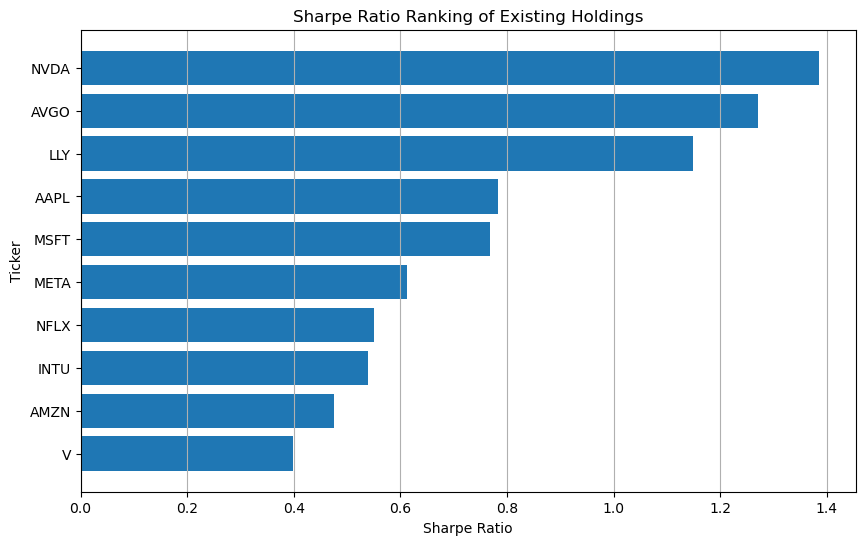

Sharpe Ratio ranking chart saved.


In [64]:
# Plot Sharpe Ratio ranking for individual stocks

sharpe_ranking = risk_return_summary["Sharpe Ratio"].sort_values(ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(sharpe_ranking.index, sharpe_ranking.values)

plt.xlabel("Sharpe Ratio")
plt.ylabel("Ticker")
plt.title("Sharpe Ratio Ranking of Existing Holdings")
plt.grid(axis="x")

plt.savefig("../charts/sharpe_ratio_ranking.png", dpi=300, bbox_inches="tight")
plt.show()

print("Sharpe Ratio ranking chart saved.")

In [65]:
# Candidate stocks for the remaining 40.60% allocation
candidate_tickers = ["JPM", "XOM", "PG", "KO", "JNJ", "UNH", "COST", "CAT", "NEE", "RTX"]

print("Candidate tickers:", candidate_tickers)

Candidate tickers: ['JPM', 'XOM', 'PG', 'KO', 'JNJ', 'UNH', 'COST', 'CAT', 'NEE', 'RTX']


In [66]:
# Download monthly price data for candidate stocks

candidate_raw_data = yf.download(
    candidate_tickers,
    start=start_date,
    end=end_date,
    interval="1mo",
    auto_adjust=True
)

candidate_raw_data.head()

[*********************100%***********************]  10 of 10 completed


Price            Close                                                 \
Ticker             CAT        COST         JNJ         JPM         KO   
Date                                                                    
2020-01-01  115.454063  278.539276  125.074692  111.102386  48.250057   
2020-02-01  109.970505  256.312378  112.984772   98.087898  44.193409   
2020-03-01  102.712280  260.497986  110.872780   76.055939  36.559326   
2020-04-01  103.013237  276.824280  126.861511   80.896545  38.246803   
2020-05-01  107.308777  282.465668  125.770782   83.060219  38.905231   

Price                                                                ...  \
Ticker            NEE          PG        RTX         UNH        XOM  ...   
Date                                                                 ...   
2020-01-01  57.418732  105.762238  81.663391  245.155518  46.705132  ...   
2020-02-01  54.113197   96.666748  71.001495  229.417694  38.675339  ...   
2020-03-01  51.783180   93.909225  51.531078  224.396744  28.957722  ...   
2020-04-01  49.738712  100.628014  56.258137  264.309784  35.440224  ...   
2020-05-01  54.998379   99.623253  56.006386  275.497833  34.677586  ...   

Price          Volume                                                         \
Ticker            CAT       COST        JNJ        JPM         KO        NEE   
Date                                                                           
2020-01-01   64504300   43480800  150462900  247990900  286856700  158862000   
2020-02-01   73414400   43434600  147288300  240714700  245599100  204372400   
2020-03-01  157650200  125473600  355927400  734330700  693439800  428186400   
2020-04-01  116563800   74411200  234380900  531938200  395209600  240284000   
2020-05-01   84708000   60875800  136206100  497858600  382765600  200519600   

Price                                                    
Ticker             PG        RTX        UNH         XOM  
Date                                                     
2020-01-01  154118600  120760982   84374200   359133900  
2020-02-01  149843900  162492731   94529600   479874900  
2020-03-01  343541300  418295352  189875500  1171277200  
2020-04-01  245058600  332896216  104539500   791507100  
2020-05-01  157315400  280146400   86558300   477169600  

[5 rows x 50 columns]

In [67]:
# Extract close prices for candidate stocks
candidate_prices = candidate_raw_data["Close"]

candidate_prices.head()

Ticker,CAT,COST,JNJ,JPM,KO,NEE,PG,RTX,UNH,XOM
Date,,,,,,,,,,
2020-01-01,115.454063,278.539276,125.074692,111.102386,48.250057,57.418732,105.762238,81.663391,245.155518,46.705132
2020-02-01,109.970505,256.312378,112.984772,98.087898,44.193409,54.113197,96.666748,71.001495,229.417694,38.675339
2020-03-01,102.712280,260.497986,110.872780,76.055939,36.559326,51.783180,93.909225,51.531078,224.396744,28.957722
2020-04-01,103.013237,276.824280,126.861511,80.896545,38.246803,49.738712,100.628014,56.258137,264.309784,35.440224
2020-05-01,107.308777,282.465668,125.770782,83.060219,38.905231,54.998379,99.623253,56.006386,275.497833,34.677586


In [68]:
# Check candidate price data quality

print("Candidate price data shape:")
print(candidate_prices.shape)

print("\nMissing values in candidate prices:")
print(candidate_prices.isna().sum())

Candidate price data shape:
(72, 10)

Missing values in candidate prices:
Ticker
CAT     0
COST    0
JNJ     0
JPM     0
KO      0
NEE     0
PG      0
RTX     0
UNH     0
XOM     0
dtype: int64


In [69]:
# Calculate monthly returns for candidate stocks
candidate_returns = candidate_prices.pct_change(fill_method=None).dropna()

print("Candidate returns shape:")
print(candidate_returns.shape)

print("\nMissing values in candidate returns:")
print(candidate_returns.isna().sum())

candidate_returns.head()

Candidate returns shape:
(71, 10)

Missing values in candidate returns:
Ticker
CAT     0
COST    0
JNJ     0
JPM     0
KO      0
NEE     0
PG      0
RTX     0
UNH     0
XOM     0
dtype: int64


Ticker,CAT,COST,JNJ,JPM,KO,NEE,PG,RTX,UNH,XOM
Date,,,,,,,,,,
2020-02-01,-0.047496,-0.079798,-0.096662,-0.117140,-0.084076,-0.057569,-0.085999,-0.130559,-0.064195,-0.171925
2020-03-01,-0.066002,0.016330,-0.018693,-0.224614,-0.172743,-0.043058,-0.028526,-0.274225,-0.021886,-0.251261
2020-04-01,0.002930,0.062673,0.144208,0.063645,0.046157,-0.039481,0.071546,0.091732,0.177868,0.223861
2020-05-01,0.041699,0.020379,-0.008598,0.026746,0.017215,0.105746,-0.009985,-0.004475,0.042329,-0.021519
2020-06-01,0.053026,-0.017052,-0.048034,-0.033398,-0.042845,-0.060221,0.031487,-0.036487,-0.032475,0.002575


In [70]:
# Save candidate stock price and return data

candidate_prices.to_csv("../data/raw/candidate_monthly_stock_prices.csv")
candidate_returns.to_csv("../data/processed/candidate_monthly_returns.csv")

print("Candidate stock prices and returns saved.")

Candidate stock prices and returns saved.


In [71]:
# Calculate risk-return metrics for candidate stocks

candidate_annualised_return = candidate_returns.mean() * 12
candidate_annualised_volatility = candidate_returns.std() * np.sqrt(12)

candidate_risk_return_summary = pd.DataFrame({
    "Annualised Return": candidate_annualised_return,
    "Annualised Volatility": candidate_annualised_volatility
})

# Add Sharpe Ratio using the same risk-free rate
candidate_risk_return_summary["Sharpe Ratio"] = (
    candidate_risk_return_summary["Annualised Return"] - risk_free_rate
) / candidate_risk_return_summary["Annualised Volatility"]

# Create percentage version for easier reading
candidate_risk_return_summary_percent = candidate_risk_return_summary.copy()
candidate_risk_return_summary_percent["Annualised Return"] = candidate_risk_return_summary_percent["Annualised Return"] * 100
candidate_risk_return_summary_percent["Annualised Volatility"] = candidate_risk_return_summary_percent["Annualised Volatility"] * 100

candidate_risk_return_summary_percent

,Annualised Return,Annualised Volatility,Sharpe Ratio
Ticker,,,
CAT,32.191433,32.111389,0.881975
COST,21.699896,22.457459,0.793941
JNJ,9.992646,17.781960,0.344318
JPM,21.478563,26.659793,0.660491
KO,7.841180,18.918272,0.209912
NEE,8.744509,25.417052,0.191781
PG,6.402122,17.574754,0.144077
RTX,17.782313,28.797844,0.483103
UNH,9.160162,29.334116,0.180342


In [72]:
# Save candidate risk-return summary

candidate_risk_return_summary_percent.to_csv(
    "../outputs/candidate_risk_return_summary.csv"
)

print("Candidate risk-return summary saved.")

Candidate risk-return summary saved.


In [73]:
# Rank candidate stocks by Sharpe Ratio

candidate_ranking_by_sharpe = candidate_risk_return_summary_percent.sort_values(
    by="Sharpe Ratio",
    ascending=False
)

candidate_ranking_by_sharpe

,Annualised Return,Annualised Volatility,Sharpe Ratio
Ticker,,,
CAT,32.191433,32.111389,0.881975
COST,21.699896,22.457459,0.793941
JPM,21.478563,26.659793,0.660491
XOM,20.796537,31.454120,0.538134
RTX,17.782313,28.797844,0.483103
JNJ,9.992646,17.781960,0.344318
KO,7.841180,18.918272,0.209912
NEE,8.744509,25.417052,0.191781
UNH,9.160162,29.334116,0.180342


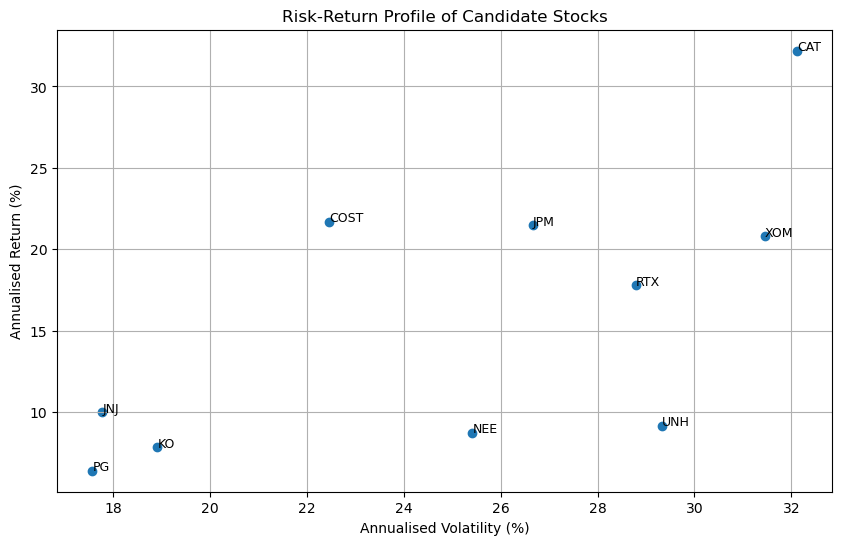

Candidate risk-return scatter chart saved.


In [74]:
# Plot risk-return profile of candidate stocks

plt.figure(figsize=(10, 6))

plt.scatter(
    candidate_risk_return_summary_percent["Annualised Volatility"],
    candidate_risk_return_summary_percent["Annualised Return"]
)

for ticker in candidate_risk_return_summary_percent.index:
    plt.text(
        candidate_risk_return_summary_percent.loc[ticker, "Annualised Volatility"],
        candidate_risk_return_summary_percent.loc[ticker, "Annualised Return"],
        ticker,
        fontsize=9
    )

plt.xlabel("Annualised Volatility (%)")
plt.ylabel("Annualised Return (%)")
plt.title("Risk-Return Profile of Candidate Stocks")
plt.grid(True)

plt.savefig("../charts/candidate_risk_return_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

print("Candidate risk-return scatter chart saved.")

In [75]:
# Combine existing holdings returns and candidate stock returns

combined_returns = pd.concat(
    [monthly_returns, candidate_returns],
    axis=1
)

print("Combined returns shape:")
print(combined_returns.shape)

combined_returns.head()

Combined returns shape:
(71, 20)


Ticker,AAPL,AMZN,AVGO,INTU,LLY,META,MSFT,NFLX,NVDA,V,CAT,COST,JNJ,JPM,KO,NEE,PG,RTX,UNH,XOM
Date,,,,,,,,,,,,,,,,,,,,
2020-02-01,-0.116798,-0.062214,-0.106633,-0.049978,-0.096749,-0.046753,-0.048288,0.069373,0.142283,-0.086496,-0.047496,-0.079798,-0.096662,-0.117140,-0.084076,-0.057569,-0.085999,-0.130559,-0.064195,-0.171925
2020-03-01,-0.067554,0.035021,-0.130291,-0.134850,0.105518,-0.133371,-0.023883,0.017532,-0.023373,-0.112272,-0.066002,0.016330,-0.018693,-0.224614,-0.172743,-0.043058,-0.028526,-0.274225,-0.021886,-0.251261
2020-04-01,0.155374,0.268900,0.165065,0.173087,0.114763,0.227278,0.136326,0.118109,0.108801,0.109235,0.002930,0.062673,0.144208,0.063645,0.046157,-0.039481,0.071546,0.091732,0.177868,0.223861
2020-05-01,0.082165,-0.012785,0.072344,0.078341,-0.010928,0.099555,0.022543,-0.000286,0.214657,0.092435,0.041699,0.020379,-0.008598,0.026746,0.017215,0.105746,-0.009985,-0.004475,0.042329,-0.021519
2020-06-01,0.150492,0.129567,0.083565,0.020219,0.078476,0.008797,0.113653,0.084126,0.070109,-0.008946,0.053026,-0.017052,-0.048034,-0.033398,-0.042845,-0.060221,0.031487,-0.036487,-0.032475,0.002575


In [76]:
# Calculate average correlation between each candidate stock and existing holdings

average_correlation_with_existing = {}

for candidate in candidate_tickers:
    correlations = combined_returns[monthly_returns.columns].corrwith(
        combined_returns[candidate]
    )
    average_correlation_with_existing[candidate] = correlations.mean()

average_correlation_with_existing = pd.Series(
    average_correlation_with_existing,
    name="Average Correlation with Existing Holdings"
)

average_correlation_with_existing.sort_values()

UNH     0.064380
XOM     0.116136
RTX     0.157468
JNJ     0.174427
NEE     0.174802
KO      0.187391
PG      0.196451
CAT     0.289571
JPM     0.334227
COST    0.415888
Name: Average Correlation with Existing Holdings, dtype: float64

In [77]:
# Combine candidate risk-return metrics with average correlation

candidate_screening_table = candidate_risk_return_summary_percent.copy()

candidate_screening_table["Average Correlation with Existing Holdings"] = (
    average_correlation_with_existing
)

candidate_screening_table = candidate_screening_table.sort_values(
    by="Average Correlation with Existing Holdings",
    ascending=True
)

candidate_screening_table

,Annualised Return,Annualised Volatility,Sharpe Ratio,Average Correlation with Existing Holdings
Ticker,,,,
UNH,9.160162,29.334116,0.180342,0.064380
XOM,20.796537,31.454120,0.538134,0.116136
RTX,17.782313,28.797844,0.483103,0.157468
JNJ,9.992646,17.781960,0.344318,0.174427
NEE,8.744509,25.417052,0.191781,0.174802
KO,7.841180,18.918272,0.209912,0.187391
PG,6.402122,17.574754,0.144077,0.196451
CAT,32.191433,32.111389,0.881975,0.289571
JPM,21.478563,26.659793,0.660491,0.334227


In [78]:
# Save candidate screening table

candidate_screening_table.to_csv("../outputs/candidate_screening_table.csv")

print("Candidate screening table saved.")

Candidate screening table saved.


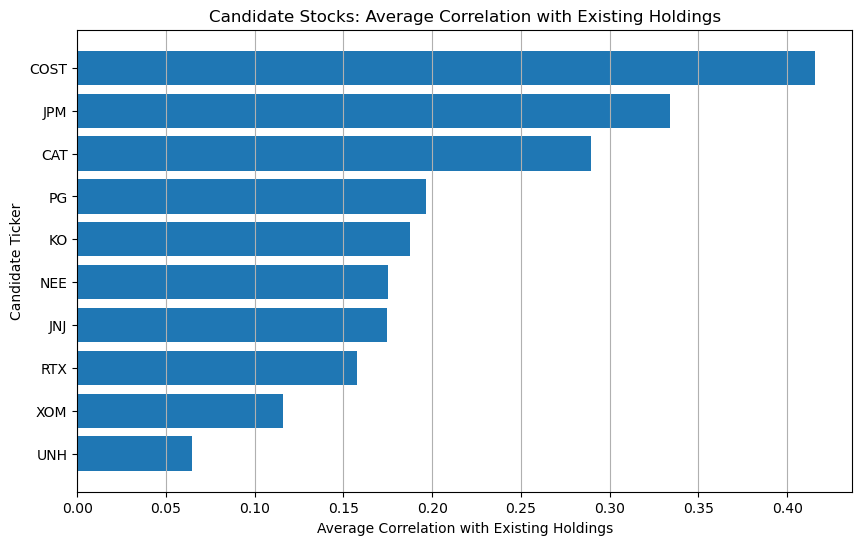

Candidate average correlation chart saved.


In [79]:
# Plot average correlation of candidate stocks with existing holdings

correlation_ranking = average_correlation_with_existing.sort_values(ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(correlation_ranking.index, correlation_ranking.values)

plt.xlabel("Average Correlation with Existing Holdings")
plt.ylabel("Candidate Ticker")
plt.title("Candidate Stocks: Average Correlation with Existing Holdings")
plt.grid(axis="x")

plt.savefig("../charts/candidate_average_correlation_with_existing.png", dpi=300, bbox_inches="tight")
plt.show()

print("Candidate average correlation chart saved.")

In [80]:
# View candidate screening table sorted by average correlation
candidate_screening_table

,Annualised Return,Annualised Volatility,Sharpe Ratio,Average Correlation with Existing Holdings
Ticker,,,,
UNH,9.160162,29.334116,0.180342,0.064380
XOM,20.796537,31.454120,0.538134,0.116136
RTX,17.782313,28.797844,0.483103,0.157468
JNJ,9.992646,17.781960,0.344318,0.174427
NEE,8.744509,25.417052,0.191781,0.174802
KO,7.841180,18.918272,0.209912,0.187391
PG,6.402122,17.574754,0.144077,0.196451
CAT,32.191433,32.111389,0.881975,0.289571
JPM,21.478563,26.659793,0.660491,0.334227


In [81]:
# View candidate screening table sorted by Sharpe Ratio
candidate_screening_table.sort_values(
    by="Sharpe Ratio",
    ascending=False
)

,Annualised Return,Annualised Volatility,Sharpe Ratio,Average Correlation with Existing Holdings
Ticker,,,,
CAT,32.191433,32.111389,0.881975,0.289571
COST,21.699896,22.457459,0.793941,0.415888
JPM,21.478563,26.659793,0.660491,0.334227
XOM,20.796537,31.454120,0.538134,0.116136
RTX,17.782313,28.797844,0.483103,0.157468
JNJ,9.992646,17.781960,0.344318,0.174427
KO,7.841180,18.918272,0.209912,0.187391
NEE,8.744509,25.417052,0.191781,0.174802
UNH,9.160162,29.334116,0.180342,0.064380


In [82]:
# New allocation weights for the remaining 40.60%

new_allocation_weights = {
    "CAT": 0.0800,
    "XOM": 0.0750,
    "RTX": 0.0700,
    "JPM": 0.0650,
    "JNJ": 0.0600,
    "PG": 0.0560
}

new_allocation_weights = pd.Series(new_allocation_weights)

print("New allocation weight sum:", new_allocation_weights.sum())

new_allocation_weights

New allocation weight sum: 0.406


CAT    0.080
XOM    0.075
RTX    0.070
JPM    0.065
JNJ    0.060
PG     0.056
dtype: float64

In [83]:
# Save new allocation weights

new_allocation_weights_table = pd.DataFrame({
    "New Allocation Weight": new_allocation_weights,
    "New Allocation Weight (%)": new_allocation_weights * 100
})

new_allocation_weights_table.to_csv("../outputs/new_allocation_weights.csv")

new_allocation_weights_table

,New Allocation Weight,New Allocation Weight (%)
CAT,0.080,8.0
XOM,0.075,7.5
RTX,0.070,7.0
JPM,0.065,6.5
JNJ,0.060,6.0
PG,0.056,5.6


In [84]:
# Select returns of chosen candidate stocks

selected_candidate_tickers = list(new_allocation_weights.index)

selected_candidate_returns = candidate_returns[selected_candidate_tickers]

selected_candidate_returns.head()

Ticker,CAT,XOM,RTX,JPM,JNJ,PG
Date,,,,,,
2020-02-01,-0.047496,-0.171925,-0.130559,-0.117140,-0.096662,-0.085999
2020-03-01,-0.066002,-0.251261,-0.274225,-0.224614,-0.018693,-0.028526
2020-04-01,0.002930,0.223861,0.091732,0.063645,0.144208,0.071546
2020-05-01,0.041699,-0.021519,-0.004475,0.026746,-0.008598,-0.009985
2020-06-01,0.053026,0.002575,-0.036487,-0.033398,-0.048034,0.031487


In [85]:
# Combine existing holdings returns and selected candidate returns

full_portfolio_returns_data = pd.concat(
    [monthly_returns, selected_candidate_returns],
    axis=1
)

print("Full portfolio return data shape:")
print(full_portfolio_returns_data.shape)

full_portfolio_returns_data.head()

Full portfolio return data shape:
(71, 16)


Ticker,AAPL,AMZN,AVGO,INTU,LLY,META,MSFT,NFLX,NVDA,V,CAT,XOM,RTX,JPM,JNJ,PG
Date,,,,,,,,,,,,,,,,
2020-02-01,-0.116798,-0.062214,-0.106633,-0.049978,-0.096749,-0.046753,-0.048288,0.069373,0.142283,-0.086496,-0.047496,-0.171925,-0.130559,-0.117140,-0.096662,-0.085999
2020-03-01,-0.067554,0.035021,-0.130291,-0.134850,0.105518,-0.133371,-0.023883,0.017532,-0.023373,-0.112272,-0.066002,-0.251261,-0.274225,-0.224614,-0.018693,-0.028526
2020-04-01,0.155374,0.268900,0.165065,0.173087,0.114763,0.227278,0.136326,0.118109,0.108801,0.109235,0.002930,0.223861,0.091732,0.063645,0.144208,0.071546
2020-05-01,0.082165,-0.012785,0.072344,0.078341,-0.010928,0.099555,0.022543,-0.000286,0.214657,0.092435,0.041699,-0.021519,-0.004475,0.026746,-0.008598,-0.009985
2020-06-01,0.150492,0.129567,0.083565,0.020219,0.078476,0.008797,0.113653,0.084126,0.070109,-0.008946,0.053026,0.002575,-0.036487,-0.033398,-0.048034,0.031487


In [86]:
# Combine existing holdings weights and new allocation weights

full_portfolio_weights = pd.concat([
    existing_weights,
    new_allocation_weights
])

# Align weights with full portfolio return data columns
full_portfolio_weights = full_portfolio_weights[full_portfolio_returns_data.columns]

print("Full portfolio weight sum:", full_portfolio_weights.sum())

full_portfolio_weights

Full portfolio weight sum: 1.0


Ticker
AAPL    0.0535
AMZN    0.0922
AVGO    0.0481
INTU    0.0368
LLY     0.0292
META    0.0633
MSFT    0.0965
NFLX    0.0338
NVDA    0.0981
V       0.0425
CAT     0.0800
XOM     0.0750
RTX     0.0700
JPM     0.0650
JNJ     0.0600
PG      0.0560
dtype: float64

In [87]:
# Save full portfolio weights

full_portfolio_weights_table = pd.DataFrame({
    "Full Portfolio Weight": full_portfolio_weights,
    "Full Portfolio Weight (%)": full_portfolio_weights * 100
})

full_portfolio_weights_table.to_csv("../outputs/full_portfolio_weights.csv")

full_portfolio_weights_table

,Full Portfolio Weight,Full Portfolio Weight (%)
Ticker,,
AAPL,0.0535,5.35
AMZN,0.0922,9.22
AVGO,0.0481,4.81
INTU,0.0368,3.68
LLY,0.0292,2.92
META,0.0633,6.33
MSFT,0.0965,9.65
NFLX,0.0338,3.38
NVDA,0.0981,9.81


In [88]:
# Calculate full portfolio monthly returns

full_portfolio_returns = full_portfolio_returns_data.dot(full_portfolio_weights)

full_portfolio_returns.head()

Date
2020-02-01   -0.060834
2020-03-01   -0.086392
2020-04-01    0.137857
2020-05-01    0.044787
2020-06-01    0.046509
dtype: float64

In [89]:
# Calculate full portfolio cumulative return index

full_portfolio_cumulative = (1 + full_portfolio_returns).cumprod()

# Add initial base value of 1.0
full_portfolio_cumulative_with_base = pd.concat([
    pd.Series([1.0], index=[prices.index[0]]),
    full_portfolio_cumulative
])

full_portfolio_cumulative_with_base.head()

2020-01-01    1.000000
2020-02-01    0.939166
2020-03-01    0.858030
2020-04-01    0.976315
2020-05-01    1.020041
dtype: float64

In [91]:
# Create full portfolio summary table

full_portfolio_summary = pd.DataFrame({
    "Metric": [
        "Annualised Return",
        "Annualised Volatility",
        "Sharpe Ratio"
    ],
    "Value": [
        full_portfolio_annualised_return,
        full_portfolio_annualised_volatility,
        full_portfolio_sharpe
    ],
    "Value (%)": [
        full_portfolio_annualised_return * 100,
        full_portfolio_annualised_volatility * 100,
        ""
    ]
})

full_portfolio_summary

,Metric,Value,Value (%)
0,Annualised Return,0.274725,27.472517
1,Annualised Volatility,0.187868,18.786812
2,Sharpe Ratio,1.256334,


In [92]:
full_portfolio_summary.to_csv(
    "../outputs/full_portfolio_summary.csv",
    index=False
)

print("Full portfolio summary updated and saved.")

Full portfolio summary updated and saved.


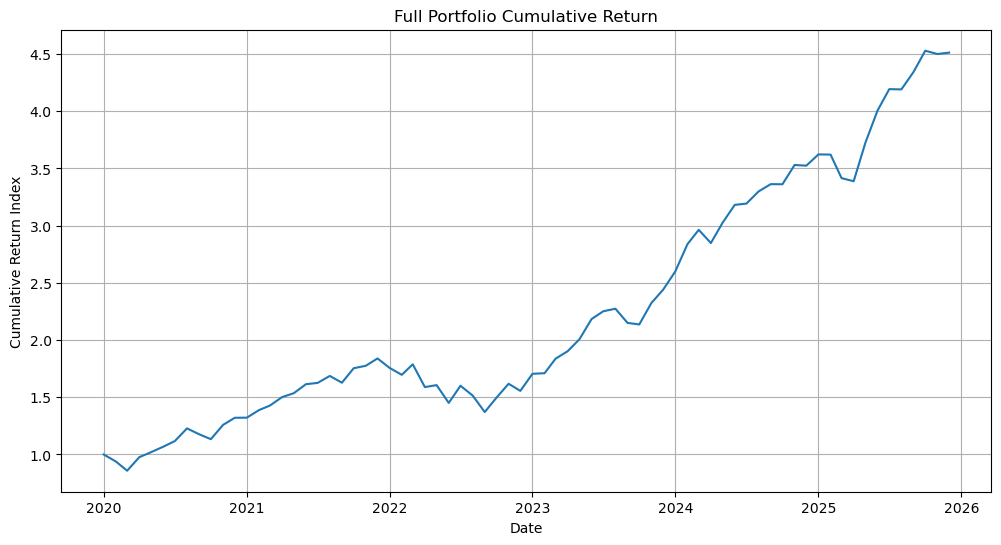

Full portfolio cumulative return chart saved.


In [93]:
# Plot full portfolio cumulative return

plt.figure(figsize=(12, 6))

plt.plot(
    full_portfolio_cumulative_with_base.index,
    full_portfolio_cumulative_with_base
)

plt.xlabel("Date")
plt.ylabel("Cumulative Return Index")
plt.title("Full Portfolio Cumulative Return")
plt.grid(True)

plt.savefig("../charts/full_portfolio_cumulative_return.png", dpi=300, bbox_inches="tight")
plt.show()

print("Full portfolio cumulative return chart saved.")

In [94]:
# Calculate full portfolio drawdown

full_portfolio_running_max = full_portfolio_cumulative_with_base.cummax()

full_portfolio_drawdown = full_portfolio_cumulative_with_base / full_portfolio_running_max - 1

full_portfolio_max_drawdown = full_portfolio_drawdown.min()

print("Full Portfolio Maximum Drawdown:", full_portfolio_max_drawdown)
print("Full Portfolio Maximum Drawdown (%):", full_portfolio_max_drawdown * 100)

Full Portfolio Maximum Drawdown: -0.25472265125845805
Full Portfolio Maximum Drawdown (%): -25.472265125845805


In [95]:
# Save full portfolio drawdown results

full_portfolio_drawdown_table = pd.DataFrame({
    "Full Portfolio Drawdown": full_portfolio_drawdown
})

full_portfolio_drawdown_summary = pd.DataFrame({
    "Metric": ["Maximum Drawdown"],
    "Value": [full_portfolio_max_drawdown],
    "Value (%)": [full_portfolio_max_drawdown * 100]
})

full_portfolio_drawdown_table.to_csv("../outputs/full_portfolio_drawdown_series.csv")
full_portfolio_drawdown_summary.to_csv("../outputs/full_portfolio_max_drawdown_summary.csv", index=False)

print("Full portfolio drawdown results saved.")

Full portfolio drawdown results saved.


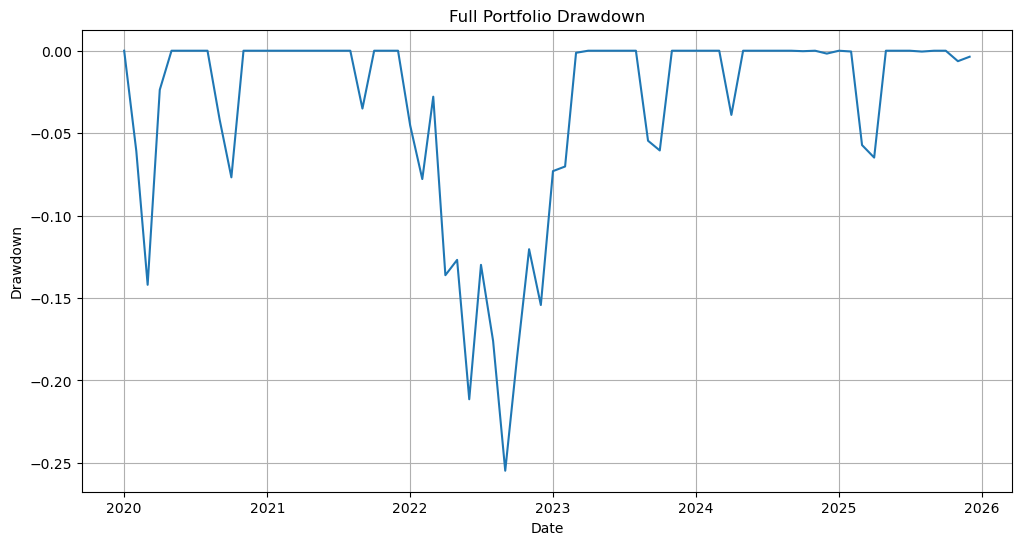

Full portfolio drawdown chart saved.


In [96]:
# Plot full portfolio drawdown

plt.figure(figsize=(12, 6))

plt.plot(
    full_portfolio_drawdown.index,
    full_portfolio_drawdown
)

plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.title("Full Portfolio Drawdown")
plt.grid(True)

plt.savefig("../charts/full_portfolio_drawdown.png", dpi=300, bbox_inches="tight")
plt.show()

print("Full portfolio drawdown chart saved.")

In [97]:
# Compare existing holdings sleeve portfolio with full portfolio

comparison_summary = pd.DataFrame({
    "Portfolio": [
        "Existing Holdings Sleeve Portfolio",
        "Full Portfolio"
    ],
    "Annualised Return": [
        existing_sleeve_annualised_return,
        full_portfolio_annualised_return
    ],
    "Annualised Volatility": [
        existing_sleeve_annualised_volatility,
        full_portfolio_annualised_volatility
    ],
    "Sharpe Ratio": [
        existing_sleeve_sharpe,
        full_portfolio_sharpe
    ],
    "Maximum Drawdown": [
        existing_sleeve_max_drawdown,
        full_portfolio_max_drawdown
    ]
})

comparison_summary_percent = comparison_summary.copy()

comparison_summary_percent["Annualised Return (%)"] = comparison_summary_percent["Annualised Return"] * 100
comparison_summary_percent["Annualised Volatility (%)"] = comparison_summary_percent["Annualised Volatility"] * 100
comparison_summary_percent["Maximum Drawdown (%)"] = comparison_summary_percent["Maximum Drawdown"] * 100

comparison_summary_percent = comparison_summary_percent[
    [
        "Portfolio",
        "Annualised Return (%)",
        "Annualised Volatility (%)",
        "Sharpe Ratio",
        "Maximum Drawdown (%)"
    ]
]

comparison_summary_percent

,Portfolio,Annualised Return (%),Annualised Volatility (%),Sharpe Ratio,Maximum Drawdown (%)
0,Existing Holdings Sleeve Portfolio,33.229826,24.663165,1.190432,-37.533016
1,Full Portfolio,27.472517,18.786812,1.256334,-25.472265


In [98]:
# Save portfolio comparison summary

comparison_summary_percent.to_csv(
    "../outputs/portfolio_comparison_summary.csv",
    index=False
)

print("Portfolio comparison summary saved.")

Portfolio comparison summary saved.


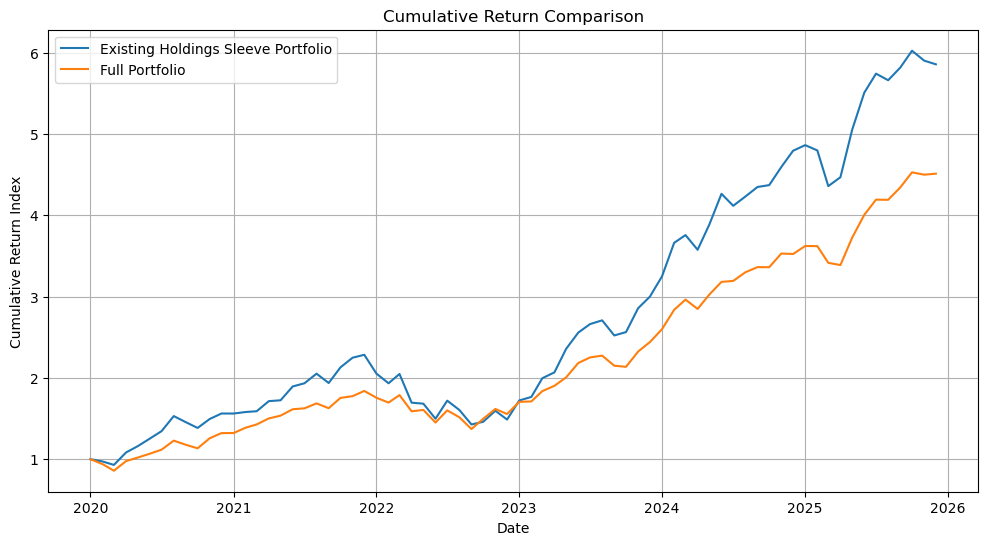

Cumulative return comparison chart saved.


In [99]:
# Plot cumulative return comparison

plt.figure(figsize=(12, 6))

plt.plot(
    existing_sleeve_cumulative_with_base.index,
    existing_sleeve_cumulative_with_base,
    label="Existing Holdings Sleeve Portfolio"
)

plt.plot(
    full_portfolio_cumulative_with_base.index,
    full_portfolio_cumulative_with_base,
    label="Full Portfolio"
)

plt.xlabel("Date")
plt.ylabel("Cumulative Return Index")
plt.title("Cumulative Return Comparison")
plt.legend()
plt.grid(True)

plt.savefig("../charts/cumulative_return_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("Cumulative return comparison chart saved.")

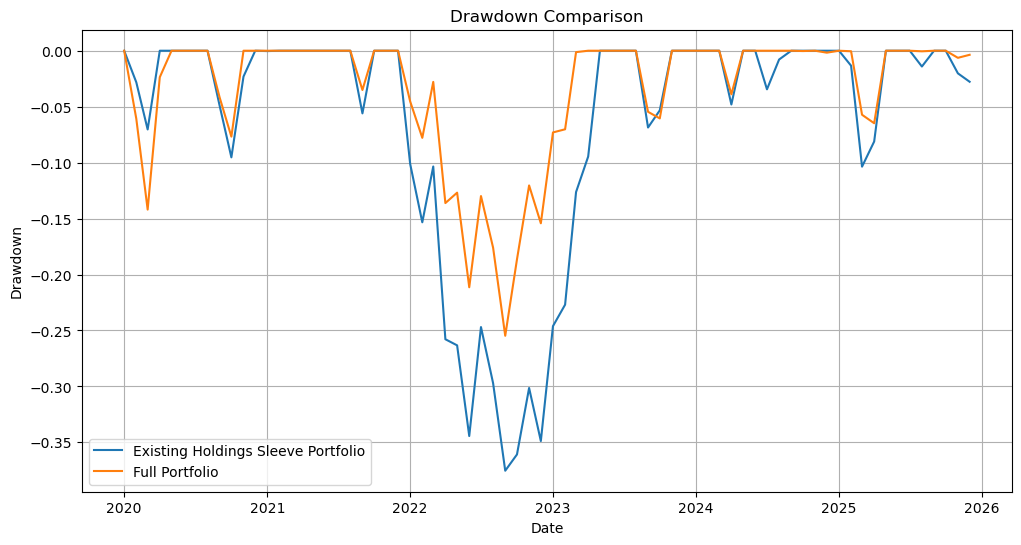

Drawdown comparison chart saved.


In [100]:
# Plot drawdown comparison

plt.figure(figsize=(12, 6))

plt.plot(
    existing_sleeve_drawdown.index,
    existing_sleeve_drawdown,
    label="Existing Holdings Sleeve Portfolio"
)

plt.plot(
    full_portfolio_drawdown.index,
    full_portfolio_drawdown,
    label="Full Portfolio"
)

plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.title("Drawdown Comparison")
plt.legend()
plt.grid(True)

plt.savefig("../charts/drawdown_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("Drawdown comparison chart saved.")

In [101]:
import os

final_expected_files = {
    "../outputs": [
        "portfolio_comparison_summary.csv",
        "full_portfolio_summary.csv",
        "full_portfolio_weights.csv",
        "candidate_screening_table.csv",
        "existing_sleeve_portfolio_summary_with_sharpe.csv"
    ],
    "../charts": [
        "cumulative_return_comparison.png",
        "drawdown_comparison.png",
        "full_portfolio_cumulative_return.png",
        "full_portfolio_drawdown.png",
        "candidate_average_correlation_with_existing.png"
    ]
}

for folder, files in final_expected_files.items():
    print("\n" + "="*60)
    print(f"Checking: {folder}")
    print("="*60)
    
    for file in files:
        path = os.path.join(folder, file)
        if os.path.exists(path):
            print(f"✓ {file}")
        else:
            print(f"✗ Missing: {file}")


Checking: ../outputs
✓ portfolio_comparison_summary.csv
✓ full_portfolio_summary.csv
✓ full_portfolio_weights.csv
✓ candidate_screening_table.csv
✓ existing_sleeve_portfolio_summary_with_sharpe.csv

Checking: ../charts
✓ cumulative_return_comparison.png
✓ drawdown_comparison.png
✓ full_portfolio_cumulative_return.png
✓ full_portfolio_drawdown.png
✓ candidate_average_correlation_with_existing.png


In [102]:
comparison_summary_percent

,Portfolio,Annualised Return (%),Annualised Volatility (%),Sharpe Ratio,Maximum Drawdown (%)
0,Existing Holdings Sleeve Portfolio,33.229826,24.663165,1.190432,-37.533016
1,Full Portfolio,27.472517,18.786812,1.256334,-25.472265


## Key Findings 核心发现

### English Version

The existing holdings sleeve portfolio generated a higher annualised return of **33.23%**, but it also carried higher annualised volatility of **24.66%** and a maximum drawdown of **-37.53%**.

After allocating the remaining **40.60%** to selected candidate stocks, the full portfolio achieved an annualised return of **27.47%**, with annualised volatility reduced to **18.79%**. Although the annualised return decreased, the full portfolio showed better risk-adjusted performance, as the Sharpe Ratio improved from **1.19** to **1.26**.

The maximum drawdown also improved significantly, from **-37.53%** for the existing holdings sleeve portfolio to **-25.47%** for the full portfolio. This suggests that the additional allocation helped reduce downside risk and improve portfolio stability.

Overall, the new allocation improved diversification and produced a more balanced risk-return profile.

### 中文版本

已有持仓 sleeve portfolio 的年化收益率较高，达到 **33.23%**，但同时也承担了较高风险，年化波动率为 **24.66%**，最大回撤为 **-37.53%**。

在将剩余 **40.60%** 配置到筛选出的候选股票之后，完整组合的年化收益率为 **27.47%**，年化波动率下降至 **18.79%**。虽然年化收益率有所下降，但完整组合的风险调整后表现更好，Sharpe Ratio 从 **1.19** 提升至 **1.26**。

最大回撤也明显改善，从已有持仓 sleeve portfolio 的 **-37.53%** 降至完整组合的 **-25.47%**。这说明新增配置有助于降低下行风险，并提升组合稳定性。

总体来看，新增的 40.60% 配置改善了组合分散化效果，使完整组合形成了更加均衡的风险收益特征。

---

## Conclusion 结论

### English Version

This project demonstrates how Python can be used to support portfolio completion and risk-return analysis. Starting from an existing **59.40%** equity allocation, the analysis first evaluated the risk and return characteristics of the existing holdings. It then screened candidate stocks for the remaining **40.60%** allocation based on annualised return, volatility, Sharpe Ratio and average correlation with existing holdings.

The final portfolio sacrificed some annualised return but achieved lower volatility, a smaller maximum drawdown and a higher Sharpe Ratio. This indicates that the selected additional holdings improved the portfolio’s risk-adjusted performance and downside protection.

The project highlights that portfolio construction should not focus only on maximising return. A more balanced allocation should also consider volatility, drawdown, correlation and diversification benefits.

### 中文版本

本项目展示了如何使用 Python 支持投资组合补全和风险收益分析。项目从一个已有 **59.40%** 权重的股票持仓组合出发，首先分析已有持仓的收益率、波动率、相关性、最大回撤和 Sharpe Ratio。随后，项目基于年化收益率、年化波动率、Sharpe Ratio 以及与已有持仓的平均相关性，对候选股票进行筛选，并为剩余 **40.60%** 进行新增配置。

最终完整组合牺牲了一部分年化收益率，但实现了更低的波动率、更小的最大回撤和更高的 Sharpe Ratio。这表明新增配置改善了组合的风险调整后表现，并增强了组合的下行风险保护能力。

本项目说明，投资组合构建不应只关注收益最大化，还应综合考虑波动率、最大回撤、相关性和分散化收益。对于已有高成长、高波动持仓的组合而言，适当加入金融、能源、工业、医疗和消费防御类股票，有助于形成更加稳定和平衡的投资组合。